## EDA of Mediapipe Landmarks

#### Imports and project-root setup

In [50]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

#### 1. Load the cached landmark sequences

In [51]:
import pickle

landmark_dir = PROJECT_ROOT / "data" / "processed" / "landmarks"

with open(landmark_dir / "train_sequences.pkl", "rb") as file:
    train_sequences = pickle.load(file)

with open(landmark_dir / "validation_sequences.pkl", "rb") as file:
    validation_sequences = pickle.load(file)

print("Train sequences:", len(train_sequences))
print("Validation sequences:", len(validation_sequences))

Train sequences: 2484
Validation sequences: 633


In [52]:
sample = train_sequences[0]

print("Type:", type(sample))
print("\nAttributes:")
print(sample.__dict__.keys())

Type: <class 'src.features.landmarks.GestureSequence'>

Attributes:
dict_keys(['video', 'label', 'class_id', 'landmarks', 'hand_detected'])


#### 1.1 Contents of the cached sequences

In [53]:
print("Video:", sample.video)
print("Label:", sample.label)
print("Class ID:", sample.class_id)

print("\nLandmarks shape:", sample.landmarks.shape)
print("Landmarks dtype:", sample.landmarks.dtype)

print("\nHand detection shape:", sample.hand_detected.shape)
print("Hand detection dtype:", sample.hand_detected.dtype)

Video: 1CM1_4_R__229
Label: G11
Class ID: 14

Landmarks shape: (38, 63)
Landmarks dtype: float32

Hand detection shape: (38,)
Hand detection dtype: bool


In [54]:
first_frame = sample.landmarks[0]

print("Shape:", first_frame.shape)
print("\nFirst frame:")
print(first_frame)

Shape: (63,)

First frame:
[ 0.          0.          0.          0.04653937 -0.05355251 -0.01862258
  0.06917378 -0.12382871 -0.03143287  0.07629883 -0.16972679 -0.04658033
  0.06444052 -0.1909315  -0.06046738  0.03825551 -0.24343953 -0.01223616
  0.04450691 -0.31094882 -0.04161984  0.0650439  -0.31320104 -0.06601521
  0.08396041 -0.29144585 -0.08097935 -0.0004659  -0.23730442 -0.02070284
 -0.00491592 -0.32067996 -0.04693425  0.02067348 -0.34206676 -0.06721287
  0.04515696 -0.3428537  -0.08104295 -0.03620741 -0.20921522 -0.0340198
 -0.04270053 -0.28159207 -0.06399001 -0.0149413  -0.2920084  -0.08247242
  0.01121837 -0.28653073 -0.09267764 -0.06550965 -0.16373348 -0.04941289
 -0.05084872 -0.19556004 -0.07521745 -0.02552825 -0.2141046  -0.09036717
 -0.00127345 -0.22777092 -0.10016001]


In [55]:
print("Wrist coordinates across frames:")

print(sample.landmarks[:, :3])

Wrist coordinates across frames:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


#### 2. Mediapipe hand detection reliability

In [56]:
detection_rate = sample.hand_detected.mean()

print("Detection rate:", detection_rate)
print("Detected frames:", sample.hand_detected.sum())
print("Total frames:", len(sample.hand_detected))

Detection rate: 1.0
Detected frames: 38
Total frames: 38


In [57]:
## across all gestures

detection_rates = np.array([
    sequence.hand_detected.mean()
    for sequence in train_sequences
])

print("Number of sequences:", len(detection_rates))
print("Mean detection rate:", detection_rates.mean())
print("Median detection rate:", np.median(detection_rates))
print("Minimum detection rate:", detection_rates.min())
print("Maximum detection rate:", detection_rates.max())

Number of sequences: 2484
Mean detection rate: 0.9176445602602437
Median detection rate: 0.9807692307692307
Minimum detection rate: 0.0
Maximum detection rate: 1.0


#### 2.1 Problematic sequences

In [58]:
bins = [0, 0.5, 0.9, 0.99, 1.0]

detection_quality = pd.cut(
    detection_rates,
    bins=bins,
    include_lowest=True,
)

print(detection_quality.value_counts().sort_index())

(-0.001, 0.5]      69
(0.5, 0.9]        523
(0.9, 0.99]       830
(0.99, 1.0]      1062
Name: count, dtype: int64


#### 2.2 Check if low-detection sequences are concentrated to a gesture-class

In [59]:
detection_by_class = pd.DataFrame({
    "mean_detection_rate": [
        np.mean([
            sequence.hand_detected.mean()
            for sequence in train_sequences
            if sequence.label == label
        ])
        for label in sorted(
            {sequence.label for sequence in train_sequences}
        )
    ],
    "sequence_count": [
        sum(
            sequence.label == label
            for sequence in train_sequences
        )
        for label in sorted(
            {sequence.label for sequence in train_sequences}
        )
    ],
}, index=sorted({sequence.label for sequence in train_sequences}))

detection_by_class

,mean_detection_rate,sequence_count
B0A,0.911827,593
B0B,0.884485,592
G01,0.938418,118
G02,0.910814,118
G03,0.949992,118
G04,0.895579,119
G05,0.940390,118
G06,0.935563,118
G07,0.960919,118
G08,0.931885,118


#### 2.3 Sequences with very low detection

In [60]:
sequence_quality = sorted(
    train_sequences,
    key=lambda sequence: sequence.hand_detected.mean()
)

for sequence in sequence_quality[:10]:
    print(
        sequence.video,
        sequence.label,
        f"{sequence.hand_detected.mean():.2%}",
        len(sequence.hand_detected),
    )

1CM1_4_R__229 G02 0.00% 25
1CM1_4_R__229 G08 0.00% 35
1CM1_4_R__229 G09 0.00% 36
1CM1_4_R__230 G07 0.00% 43
1CM1_4_R__230 G02 0.00% 30
1CM1_4_R__231 G06 0.00% 34
1CM1_4_R__231 G10 0.00% 37
1CM1_4_R__231 G04 0.00% 38
1CM1_4_R__232 G03 0.00% 28
1CM1_4_R__232 G01 0.00% 38


In [61]:
from src.data.dataset import get_dataset_paths
from src.data.annotations import load_annotations

paths = get_dataset_paths()

all_annotations = load_annotations(paths.annotations)

all_annotations["frame_count"] = pd.to_numeric(
    all_annotations["frame_count"],
    errors="coerce",
)

class_details = pd.read_csv(
    paths.class_details,
    sep="\t",
    skipinitialspace=True,
)

all_annotations = all_annotations[
    all_annotations["label"].isin(class_details["Label"])
].copy()

In [62]:
problem_video = "1CM1_4_R__229"
problem_label = "G02"

problem_annotation = all_annotations[
    (all_annotations["video"] == problem_video)
    & (all_annotations["label"] == problem_label)
]

problem_annotation



,video,label,class_id,start_frame,end_frame,frame_count
11,1CM1_4_R__229,G02,5,1433,1457,25.0


#### 2.4 Locate the video, read frames and display them

In [63]:
video_path = paths.videos / f"{problem_video}.avi"

print(video_path)
print("Exists:", video_path.exists())

D:\Datasets\IPN Hand\videos\videos\1CM1_4_R__229.avi
Exists: True


In [64]:
import cv2
import matplotlib.pyplot as plt

capture = cv2.VideoCapture(str(video_path))

frames_to_check = [1433, 1440, 1450, 1457]
frames = []

for frame_number in frames_to_check:
    capture.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

    success, frame = capture.read()

    if success:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append((frame_number, frame))

capture.release()

print("Frames successfully read:", len(frames))

Frames successfully read: 4


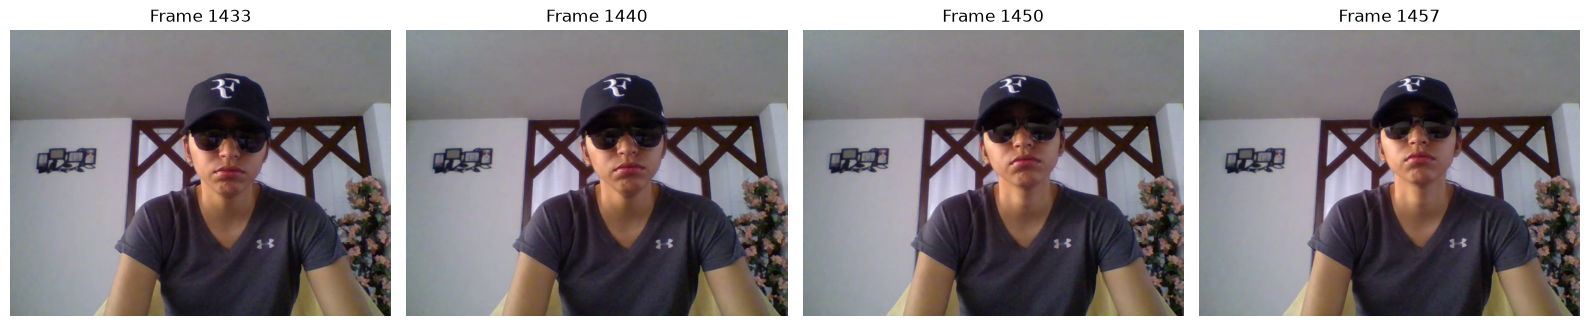

In [65]:
fig, axes = plt.subplots(1, len(frames), figsize=(16, 4))

for ax, (frame_number, frame) in zip(axes, frames):
    ax.imshow(frame)
    ax.set_title(f"Frame {frame_number}")
    ax.axis("off")

plt.tight_layout()
plt.show()

#### 2.5 Isolate the missed frames (Isolated or Contiguous)

In [66]:
def get_missing_runs(detection_mask):
    """
    Find consecutive runs of frames where the hand was not detected.

    Returns:
        List of (start_index, end_index, length) tuples.
    """
    missing = ~detection_mask

    runs = []
    start = None

    for index, is_missing in enumerate(missing):
        if is_missing and start is None:
            start = index

        elif not is_missing and start is not None:
            runs.append(
                (start, index - 1, index - start)
            )
            start = None

    # Handle a missing run that continues until the final frame.
    if start is not None:
        runs.append(
            (start, len(missing) - 1, len(missing) - start)
        )

    return runs

problem_sequence = next(
    sequence
    for sequence in train_sequences
    if sequence.video == "1CM1_4_R__229"
    and sequence.label == "G02"
)

runs = get_missing_runs(problem_sequence.hand_detected)

print("Missing runs:", runs)

Missing runs: [(0, 24, 25)]


#### 2.5.1 Find the longest missing run in every sequence

In [67]:
longest_missing_runs = np.array([
    max(
        (run[2] for run in get_missing_runs(sequence.hand_detected)),
        default=0,
    )
    for sequence in train_sequences
])

print("Mean longest missing run:", longest_missing_runs.mean())
print("Median longest missing run:", np.median(longest_missing_runs))
print("Maximum longest missing run:", longest_missing_runs.max())

Mean longest missing run: 7.667874396135265
Median longest missing run: 1.0
Maximum longest missing run: 377


#### 2.5.2 Segregate the missing runs into bins

In [68]:
run_bins = [0, 1, 3, 5, 10, 30, 100, np.inf]

run_categories = pd.cut(
    longest_missing_runs,
    bins=run_bins,
    include_lowest=True,
)

run_counts = run_categories.value_counts().sort_index()

run_counts

(-0.001, 1.0]    1416
(1.0, 3.0]        248
(3.0, 5.0]        122
(5.0, 10.0]       191
(10.0, 30.0]      317
(30.0, 100.0]     184
(100.0, inf]        6
Name: count, dtype: int64

#### 2.5.3 Determine the extreme sequences (>100)

In [69]:
extreme_sequences = []

for sequence in train_sequences:
    runs = get_missing_runs(sequence.hand_detected)
    longest_run = max(
        (run[2] for run in runs),
        default=0,
    )

    if longest_run > 100:
        extreme_sequences.append(
            (
                sequence.video,
                sequence.label,
                len(sequence.hand_detected),
                sequence.hand_detected.mean(),
                longest_run,
            )
        )

extreme_sequences

[('4CM11_14_R__21', 'G10', 184, np.float64(0.3641304347826087), 117),
 ('4CM11_16_R__209', 'G02', 525, np.float64(0.17333333333333334), 377),
 ('4CM11_5_L__10', 'B0B', 282, np.float64(0.2624113475177305), 108),
 ('4CM11_5_L__10', 'B0B', 306, np.float64(0.14052287581699346), 200),
 ('4CM11_5_L__10', 'B0B', 283, np.float64(0.07773851590106007), 135),
 ('4CM11_5_L__10', 'B0B', 169, np.float64(0.15384615384615385), 109)]

#### 2.5.4 Inspect the most extreme sequence (4CM11_16_R__209)

In [70]:
extreme_video = "4CM11_16_R__209"
extreme_label = "G02"

extreme_annotation = all_annotations[
    (all_annotations["video"] == extreme_video)
    & (all_annotations["label"] == extreme_label)
]

extreme_annotation

,video,label,class_id,start_frame,end_frame,frame_count
2942,4CM11_16_R__209,G02,5,1305,1829,525.0


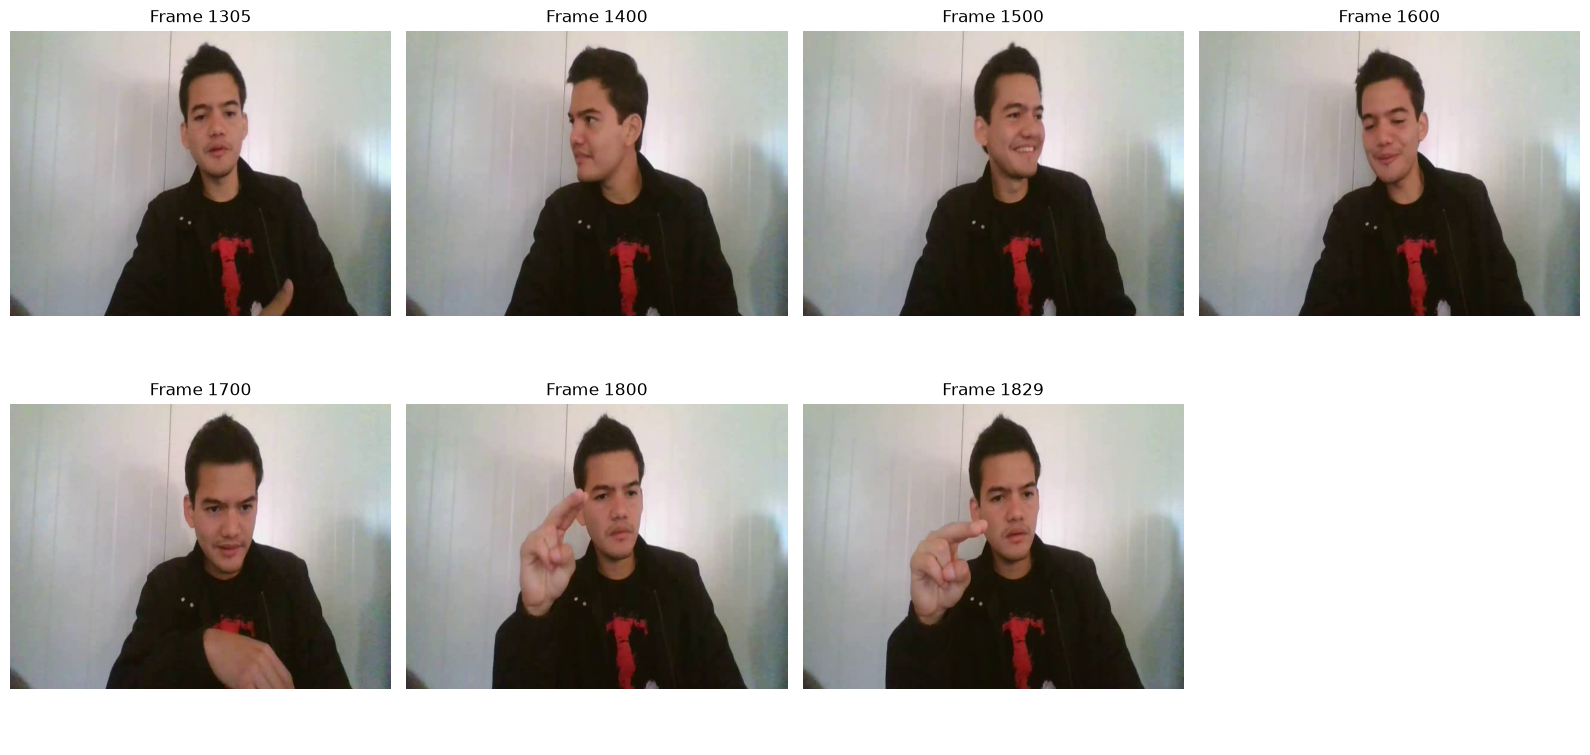

In [71]:
## inspect the actual segment
import cv2
import matplotlib.pyplot as plt

video_path = paths.videos / f"{extreme_video}.avi"

capture = cv2.VideoCapture(str(video_path))

sample_positions = [
    1305,
    1400,
    1500,
    1600,
    1700,
    1800,
    1829,
]

frames = []

for frame_number in sample_positions:
    capture.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    success, frame = capture.read()

    if success:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append((frame_number, frame))

capture.release()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for axis in axes:
    axis.axis("off")

for axis, (frame_number, frame) in zip(axes, frames):
    axis.imshow(frame)
    axis.set_title(f"Frame {frame_number}")
    axis.axis("off")

plt.tight_layout()
plt.show()

In [72]:
## find the exact position where hand appears
extreme_sequence = next(
    sequence
    for sequence in train_sequences
    if sequence.video == "4CM11_16_R__209"
    and sequence.label == "G02"
)

detection_mask = extreme_sequence.hand_detected

detected_indices = np.where(detection_mask)[0]

print("Sequence length:", len(detection_mask))
print("Detected frames:", detection_mask.sum())
print("Detection rate:", detection_mask.mean())
print("First detected frame index:", detected_indices[0])
print("Last detected frame index:", detected_indices[-1])

Sequence length: 525
Detected frames: 91
Detection rate: 0.17333333333333334
First detected frame index: 377
Last detected frame index: 524


#### 2.6 Check if different gestures produce visibly different landmark movement patterns

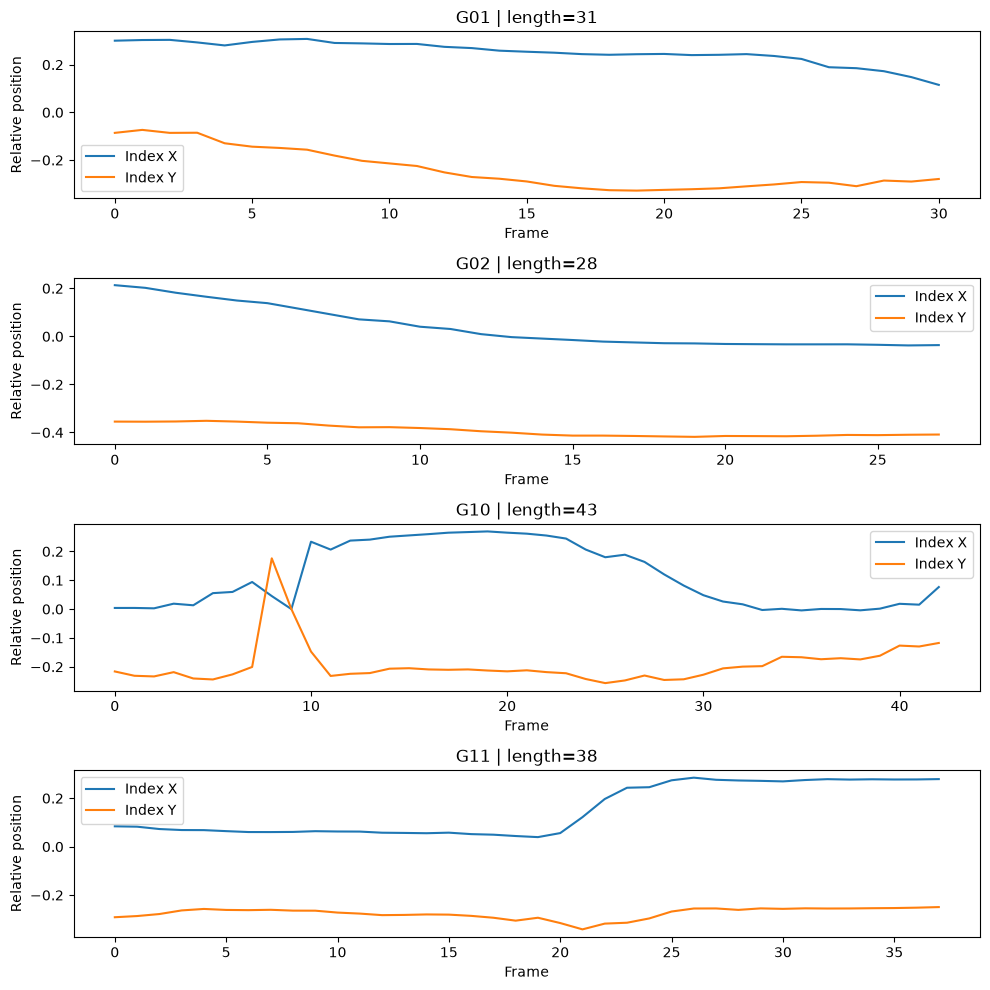

In [73]:
import matplotlib.pyplot as plt

selected_labels = ["G01", "G02", "G10", "G11"]

fig, axes = plt.subplots(
    len(selected_labels),
    1,
    figsize=(10, 10),
)

for axis, label in zip(axes, selected_labels):

    sequence = next(
        sequence
        for sequence in train_sequences
        if sequence.label == label
        and sequence.hand_detected.mean() > 0.9
    )

    index_x = sequence.landmarks[:, 24]
    index_y = sequence.landmarks[:, 25]

    axis.plot(index_x, label="Index X")
    axis.plot(index_y, label="Index Y")

    axis.set_title(
        f"{label} | length={len(sequence.landmarks)}"
    )
    axis.set_xlabel("Frame")
    axis.set_ylabel("Relative position")
    axis.legend()

plt.tight_layout()
plt.show()

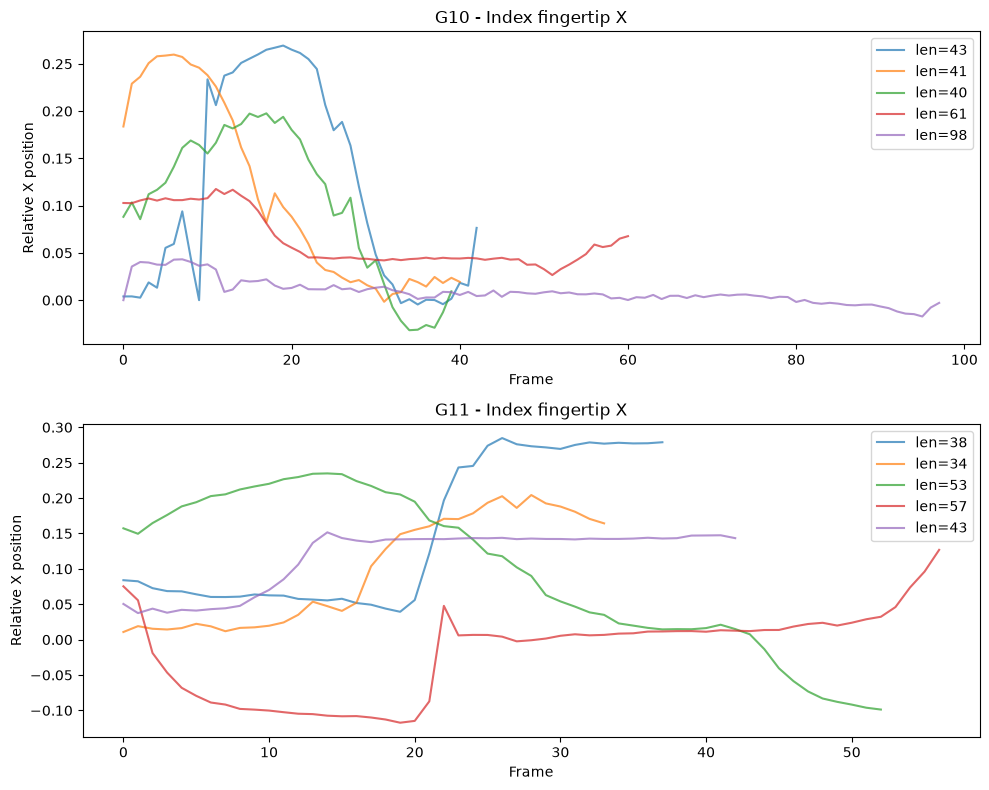

In [74]:
selected_labels = ["G10", "G11"]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 8),
)

for axis, label in zip(axes, selected_labels):

    sequences = [
        sequence
        for sequence in train_sequences
        if sequence.label == label
        and sequence.hand_detected.mean() > 0.9
    ]

    # Take five examples
    sequences = sequences[:5]

    for sequence in sequences:
        index_x = sequence.landmarks[:, 24]

        axis.plot(
            index_x,
            alpha=0.7,
            label=f"len={len(index_x)}"
        )

    axis.set_title(f"{label} - Index fingertip X")
    axis.set_xlabel("Frame")
    axis.set_ylabel("Relative X position")
    axis.legend()

plt.tight_layout()
plt.show()

1. first landmark is (0,0,0) as we have normalized the landmark values from wrist position by doing: landmarks - wrist
2. A False detection does not automatically mean MediaPipe failed.

    For a gesture segment, there may genuinely be frames where:

    the hand leaves the visible area,
    the hand is occluded,
    the gesture temporarily doesn't show a clear hand,
    or the annotation includes frames where the hand isn't clearly visible.
3. Some low-detection sequences may be caused by characteristics of particular recordings rather than gesture class alone.
4. Consecutive missing frames go up to 377, with 30 fps it accounts for about 12.6 seconds of undetected hand in the video.
5. Very long missing-detection runs can be recording-specific, rather than simply being caused by a particular gesture class. (Video 4CM11_5_L__10 accounts for 4/6 extreme missing runs and for the same gesture (B0B))
6. Don't interpolate long missing regions, it can be used for shorter sequences.
7. Landmark detection: Hand visibility varies substantially within annotated segments. Long contiguous periods of undetected landmarks can correspond to genuine absence of the hand rather than landmark-extraction failure. Therefore, long missing intervals should not be blindly interpolated. The hand_detected mask is retained as a potentially useful temporal signal.
8. GRU may have difficulty with some classes due to intra-class variation and intra-class overlap.